In [ ]:
!pip install nltk


# TOKENIZATION

1. Sentence Tokenization

In [5]:
import nltk
nltk.download('punkt_tab')

text = "Hello, how are you today?. Hope you enjoy the class"
sentence_token = nltk.sent_tokenize(text)
print(sentence_token)

['Hello, how are you today?.', 'Hope you enjoy the class']


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


2. Word Tokenization

In [6]:
import nltk
nltk.download('punkt_tab')

text = """
The stock market saw a significant dip today. Experts believe the downturn may continue.
However, many investors are optimistic about future growth.
"""

word_token = nltk.sent_tokenize(text)

# Tokenize the first sentence into words
words = nltk.word_tokenize(word_token[0])
print(words)

['The', 'stock', 'market', 'saw', 'a', 'significant', 'dip', 'today', '.']


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


# STOP WORDS

1. Accessing stop words

In [8]:
from nltk.corpus import stopwords
nltk.download('stopwords')

stop_words = stopwords.words('english')
print(stop_words[:10])

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an']


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


2. Removing stop words

In [9]:
from nltk.tokenize import word_tokenize
nltk.download('punkt')

text = "This is an example to demonstrate stop word removal."
tokens = word_tokenize(text)
filtered_tokens = [word for word in tokens if word.lower() not in stop_words]
print(filtered_tokens)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


['example', 'demonstrate', 'stop', 'word', 'removal', '.']


# PUNCTUATION

In [10]:
import string
print(string.punctuation)

!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~


In [11]:
clean_tokens = [word for word in filtered_tokens if word not in string.punctuation]
print(clean_tokens)

['example', 'demonstrate', 'stop', 'word', 'removal']


# NORMALIZATION TECHNIQUES

1. lowercasing

In [12]:
text = "Data Scientist and data engineers need DATA"
lower_text = text.lower()
print(lower_text)

data scientist and data engineers need data


2. Stemming

In [13]:
from nltk.stem import PorterStemmer
stemmer = PorterStemmer()

words = ["running", "bats", "organization", "reading"]
stemmed = [stemmer.stem(word) for word in words]
print(stemmed)

['run', 'bat', 'organ', 'read']


3. Lemmatization

In [14]:
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()

lemmatized = [lemmatizer.lemmatize(word) for word in words]
print(lemmatized)

[nltk_data] Downloading package wordnet to /root/nltk_data...


['running', 'bat', 'organization', 'reading']


# Bag of Words (BoW)

In [19]:
reviews = ["I loved the movie. It was amazing!", "The move was okay.", "I hated the movie. It was terrible."]

def preprocess_text(text):
    text = text.lower()
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in string.punctuation]
    return " ".join(tokens)

preprocessed_reviews = [preprocess_text(review) for review in reviews]
print(preprocessed_reviews)


['i loved the movie it was amazing', 'the move was okay', 'i hated the movie it was terrible']


In [25]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer()

vectorizer.fit(preprocessed_reviews)
print(vectorizer.get_feature_names_out())

bow_matrix = vectorizer.fit_transform(preprocessed_reviews)
print(bow_matrix)
print(bow_matrix.toarray())

['amazing' 'hated' 'it' 'loved' 'move' 'movie' 'okay' 'terrible' 'the'
 'was']
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 16 stored elements and shape (3, 10)>
  Coords	Values
  (0, 3)	1
  (0, 8)	1
  (0, 5)	1
  (0, 2)	1
  (0, 9)	1
  (0, 0)	1
  (1, 8)	1
  (1, 9)	1
  (1, 4)	1
  (1, 6)	1
  (2, 8)	1
  (2, 5)	1
  (2, 2)	1
  (2, 9)	1
  (2, 1)	1
  (2, 7)	1
[[1 0 1 1 0 1 0 0 1 1]
 [0 0 0 0 1 0 1 0 1 1]
 [0 1 1 0 0 1 0 1 1 1]]


Word Frequencies

In [27]:
import numpy as np

words = vectorizer.get_feature_names_out()
print(words)

word_counts = np.sum(bow_matrix.toarray(), axis=0)
print(word_counts)


['amazing' 'hated' 'it' 'loved' 'move' 'movie' 'okay' 'terrible' 'the'
 'was']
[1 1 2 1 1 2 1 1 3 3]


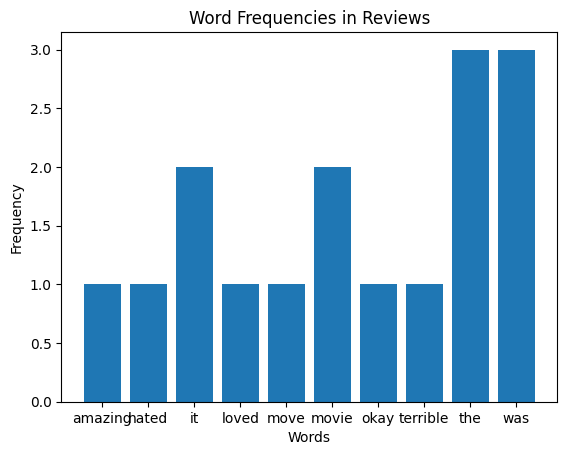

In [29]:
import matplotlib.pyplot as plt
plt.bar(words, word_counts)
plt.title("Word Frequencies in Reviews")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()



In [30]:
import pandas as pd
df = pd.DataFrame(bow_matrix.toarray(), columns=words)
print(df)

   amazing  hated  it  loved  move  movie  okay  terrible  the  was
0        1      0   1      1     0      1     0         0    1    1
1        0      0   0      0     1      0     1         0    1    1
2        0      1   1      0     0      1     0         1    1    1


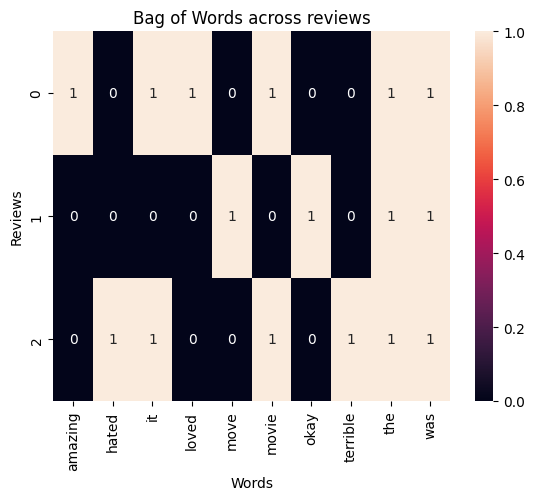

In [31]:
import seaborn as sns
sns.heatmap(df, annot=True)
plt.title("Bag of Words across reviews")
plt.xlabel("Words")
plt.ylabel("Reviews")
plt.show()

# TF-IDF

In [35]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer()

tfidf_matrix = tfidf_vectorizer.fit_transform(preprocessed_reviews)
print(tfidf_matrix)

tfidf_matrix_array = tfidf_matrix.toarray()
print(tfidf_matrix_array)

vectorizer.get_feature_names_out()

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 16 stored elements and shape (3, 10)>
  Coords	Values
  (0, 3)	0.5093526665422775
  (0, 8)	0.30083189009819455
  (0, 5)	0.3873758317012295
  (0, 2)	0.3873758317012295
  (0, 9)	0.30083189009819455
  (0, 0)	0.5093526665422775
  (1, 8)	0.35959372325985667
  (1, 9)	0.35959372325985667
  (1, 4)	0.6088450986844796
  (1, 6)	0.6088450986844796
  (2, 8)	0.30083189009819455
  (2, 5)	0.3873758317012295
  (2, 2)	0.3873758317012295
  (2, 9)	0.30083189009819455
  (2, 1)	0.5093526665422775
  (2, 7)	0.5093526665422775
[[0.50935267 0.         0.38737583 0.50935267 0.         0.38737583
  0.         0.         0.30083189 0.30083189]
 [0.         0.         0.         0.         0.6088451  0.
  0.6088451  0.         0.35959372 0.35959372]
 [0.         0.50935267 0.38737583 0.         0.         0.38737583
  0.         0.50935267 0.30083189 0.30083189]]


array(['amazing', 'hated', 'it', 'loved', 'move', 'movie', 'okay',
       'terrible', 'the', 'was'], dtype=object)

    amazing     hated        it     loved      move     movie      okay  \
0  0.509353  0.000000  0.387376  0.509353  0.000000  0.387376  0.000000   
1  0.000000  0.000000  0.000000  0.000000  0.608845  0.000000  0.608845   
2  0.000000  0.509353  0.387376  0.000000  0.000000  0.387376  0.000000   

   terrible       the       was  
0  0.000000  0.300832  0.300832  
1  0.000000  0.359594  0.359594  
2  0.509353  0.300832  0.300832  


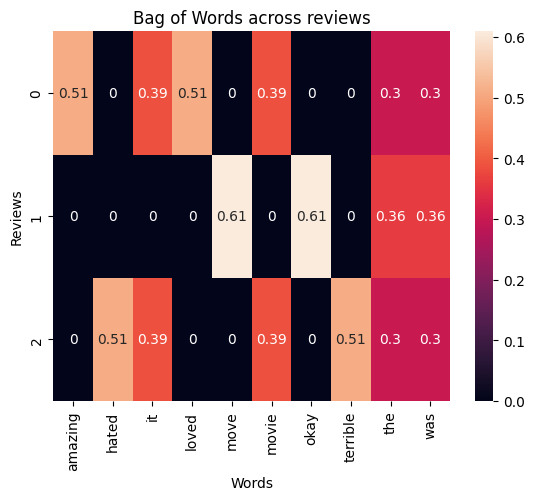

In [37]:
import pandas as pd
df_idf = pd.DataFrame(tfidf_matrix_array, columns=vectorizer.get_feature_names_out())
print(df_idf)


import seaborn as sns
sns.heatmap(df_idf, annot=True)
plt.title("Bag of Words across reviews")
plt.xlabel("Words")
plt.ylabel("Reviews")
plt.show()